# Drift combinado (covariate + concept) × Compatibilidad Stage1↔Stage2 (Diabetes Readmission)

Repite `compatibility_combined_drift.ipynb` (Physionet) sobre `diabetes_readmission`, para ver si el
hallazgo contraintuitivo de ese notebook —**A3 sola gana a A4 y a A2c+A3** bajo drift combinado— se
sostiene con un dataset distinto, más balanceado (`readmitted` ≈42% vs. sepsis ≈1.2%) y sin necesitar
la variante `_recentered` del concept drift (ver `diabetes_drift_injector.ipynb`).

**Cómo se combina el drift:** igual que en Physionet — para cada severidad, primero covariate shift
(`DriftInjector`, mezcla Beta por variable) sobre las variables clínicas, y sobre ese resultado ya
desplazado, concept drift (`ConceptDriftInjector`, mecanismo `logit_reweight`) para reetiquetar
`readmitted`.

**Acciones comparadas:** A1, A2, A3, A4, A2c+A3, y **tres variantes de A2c** — la que usamos en
Physionet (mapeo por cuantiles) más las dos que probó un compañero en `poc_compatibility.ipynb`
(media/desviación estándar, y mediana/IQR robusta) — para responder directamente si el método de
corrección de `X` cambia algo en las conclusiones.

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

from darl.data.get_dataset import load_dataset
from darl.drift import DriftInjector, ConceptDriftInjector
from darl.evaluation import ks_stat, psi_numeric
from darl.pipeline import fit_stage1, apply_stage1
from darl.actions.selective_update import (
    eval_metrics, fit_reference_quantile_map, apply_reference_quantile_map,
    fit_reference_location_scale_map, apply_reference_location_scale_map,
)

SEED = 42
np.random.seed(SEED)

CLINICAL_VARS = [
    "time_in_hospital", "num_lab_procedures", "num_procedures",
    "num_medications", "number_outpatient", "number_emergency",
    "number_inpatient", "number_diagnoses",
]
LABEL_COL = "readmitted"
THRESHOLD = 0.5
SEVERITIES = [0.0, 0.2, 0.5, 0.8, 1.0, 1.2]
CONCEPT_MECHANISM = "logit_reweight"  # plain reweight already works here (~42% prevalence, no need to recenter)
# Covariate drift is only injected into the 3 vars with a reasonably continuous spread.
# The other 5 (number_emergency, number_outpatient, number_inpatient, num_procedures,
# number_diagnoses) are heavily zero-inflated (>90% of rows exactly at the minimum for
# some of them) and trip a DriftInjector bug: `_apply_numeric` clips every row's
# reconstructed value into (EPS, 1-EPS) even when drift_severity=0, which nudges a huge
# tied-at-the-boundary mass by a hair and gets read by KS as a large "drift" that isn't
# real — violating the "severity=0 => no change" guarantee. That's a separate,
# pre-existing bug (not ours to fix here); we route around it for this notebook.
NUM_CFG = {
    "time_in_hospital": "high", "num_lab_procedures": "high", "num_medications": "high",
}

print("Imports OK")

C:\Users\dayan\OneDrive\Documentos\GitHub\tesis-darl\.venv\Lib\site-packages\xport\__about__.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


Imports OK


### Nota — sustitución de Stage 2

Igual que en los notebooks de Physionet: se usan versiones locales de A1–A4 (+ la híbrida A2c+A3) con
`LogisticRegression()` simple en vez de `darl.pipeline.make_logreg`, que tiene un bug preexistente
(solver `saga` + `class_weight="balanced"` combinado con la salida de `fit_stage1` da un modelo
degenerado). No es objetivo de estos notebooks arreglarlo.

In [2]:
def run_a1_local(df_drifted_target, qt, imputer, scaler, model, vitals, numeric_cols, label_col, threshold):
    df_t = apply_stage1(df_drifted_target, qt, imputer, scaler, vitals, numeric_cols)
    x = df_t[numeric_cols].values
    y = df_drifted_target[label_col].values
    return eval_metrics(model, x, y, threshold), 0.0


def run_a2_local(df_drifted_target, df_drifted_train, model, vitals, numeric_cols, label_col, threshold, seed=42):
    t0 = time.perf_counter()
    qt_new, imputer_new, scaler_new = fit_stage1(df_drifted_train, vitals, numeric_cols, seed)
    t_fit = time.perf_counter() - t0
    df_t = apply_stage1(df_drifted_target, qt_new, imputer_new, scaler_new, vitals, numeric_cols)
    x = df_t[numeric_cols].values
    y = df_drifted_target[label_col].values
    return eval_metrics(model, x, y, threshold), t_fit


def correct_x(df_drifted_train, df_reference_train, df_to_correct, vitals, method):
    # Three flavors of "align X toward the reference distribution", all A2c in spirit:
    # - "quantile": non-parametric marginal quantile map (what we used for Physionet).
    # - "meanstd": affine correction matching mean/std (a teammate's variant in poc_compatibility.ipynb).
    # - "medianiqr": same idea but robust (median/IQR), less sensitive to Beta-injected extremes.
    if method == "quantile":
        qmap = fit_reference_quantile_map(df_drifted_train, df_reference_train, vitals)
        return apply_reference_quantile_map(df_to_correct, qmap)
    elif method == "meanstd":
        smap = fit_reference_location_scale_map(df_drifted_train, df_reference_train, vitals, robust=False)
        return apply_reference_location_scale_map(df_to_correct, smap)
    elif method == "medianiqr":
        smap = fit_reference_location_scale_map(df_drifted_train, df_reference_train, vitals, robust=True)
        return apply_reference_location_scale_map(df_to_correct, smap)
    else:
        raise ValueError(f"unknown correction method: {method!r}")


def run_a2c_local(df_drifted_target, df_drifted_train, df_reference_train, qt_ref, imputer_ref, scaler_ref,
                  model, vitals, numeric_cols, label_col, threshold, method="quantile"):
    t0 = time.perf_counter()
    df_corrected_target = correct_x(df_drifted_train, df_reference_train, df_drifted_target, vitals, method)
    t_update = time.perf_counter() - t0
    df_t = apply_stage1(df_corrected_target, qt_ref, imputer_ref, scaler_ref, vitals, numeric_cols)
    x = df_t[numeric_cols].values
    y = df_drifted_target[label_col].values
    return eval_metrics(model, x, y, threshold), t_update


def run_a3_local(df_drifted_target, df_drifted_train, qt_ref, imputer_ref, scaler_ref,
                 vitals, numeric_cols, label_col, threshold, seed=42):
    df_tr_t = apply_stage1(df_drifted_train, qt_ref, imputer_ref, scaler_ref, vitals, numeric_cols)
    x_new = df_tr_t[numeric_cols].values
    y_new = df_drifted_train[label_col].values
    model_new = LogisticRegression(max_iter=1000)
    t0 = time.perf_counter()
    model_new.fit(x_new, y_new)
    t_fit = time.perf_counter() - t0
    df_t = apply_stage1(df_drifted_target, qt_ref, imputer_ref, scaler_ref, vitals, numeric_cols)
    x = df_t[numeric_cols].values
    y = df_drifted_target[label_col].values
    return eval_metrics(model_new, x, y, threshold), t_fit


def run_a4_local(df_drifted_target, df_drifted_train, vitals, numeric_cols, label_col, threshold, seed=42):
    t0_stage1 = time.perf_counter()
    qt_new, imputer_new, scaler_new = fit_stage1(df_drifted_train, vitals, numeric_cols, seed)
    t_stage1 = time.perf_counter() - t0_stage1
    df_tr_t = apply_stage1(df_drifted_train, qt_new, imputer_new, scaler_new, vitals, numeric_cols)
    x_new = df_tr_t[numeric_cols].values
    y_new = df_drifted_train[label_col].values
    model_new = LogisticRegression(max_iter=1000)
    t0_model = time.perf_counter()
    model_new.fit(x_new, y_new)
    t_model = time.perf_counter() - t0_model
    df_t = apply_stage1(df_drifted_target, qt_new, imputer_new, scaler_new, vitals, numeric_cols)
    x = df_t[numeric_cols].values
    y = df_drifted_target[label_col].values
    return eval_metrics(model_new, x, y, threshold), t_stage1 + t_model


def run_a2c_plus_a3_local(df_drifted_target, df_drifted_train, df_reference_train, qt_ref, imputer_ref, scaler_ref,
                          vitals, numeric_cols, label_col, threshold, seed=42, method="quantile"):
    # Cheap alternative to A4: correct X toward reference (A2c-style), keep Stage 1 frozen,
    # but retrain Stage 2 (A3-style) on the corrected X + drifted Y.
    t0 = time.perf_counter()
    df_corrected_train = correct_x(df_drifted_train, df_reference_train, df_drifted_train, vitals, method)
    df_corrected_target = correct_x(df_drifted_train, df_reference_train, df_drifted_target, vitals, method)
    t_correct = time.perf_counter() - t0

    df_tr_t = apply_stage1(df_corrected_train, qt_ref, imputer_ref, scaler_ref, vitals, numeric_cols)
    x_new = df_tr_t[numeric_cols].values
    y_new = df_drifted_train[label_col].values

    model_new = LogisticRegression(max_iter=1000)
    t0_model = time.perf_counter()
    model_new.fit(x_new, y_new)
    t_model = time.perf_counter() - t0_model

    df_t = apply_stage1(df_corrected_target, qt_ref, imputer_ref, scaler_ref, vitals, numeric_cols)
    x = df_t[numeric_cols].values
    y = df_drifted_target[label_col].values
    metrics = eval_metrics(model_new, x, y, threshold)
    return metrics, t_correct + t_model

### Nota — bug encontrado en `DriftInjector` (covariate), ajeno a este notebook

Al intentar inyectar covariate shift en las 8 variables clínicas completas, 5 de ellas
(`number_emergency`, `number_outpatient`, `number_inpatient`, `num_procedures`, `number_diagnoses`)
produjeron un KS **idéntico en todas las severidades, incluida `severity=0`** — donde no debería haber
ningún cambio. Causa: son variables de conteo con una masa enorme de valores exactamente en el mínimo
(p. ej. 92% de `number_emergency` es exactamente 0). `DriftInjector._apply_numeric` reconstruye el valor
de cada fila con `np.clip(z, EPS, 1-EPS)` **incluso para las filas no seleccionadas para driftear**, así
que ese 92% en 0 se desplaza a `7.6e-05` aunque `drift_severity=0` — un cambio ínfimo en magnitud, pero
suficiente para que el test KS lo lea como una diferencia de distribución enorme (≈0.92), porque mueve
por completo la masa que estaba exactamente en el punto de corte. Esto además arrastraba al
`ConceptDriftInjector` a etiquetas degeneradas (una sola clase) a `severity=1.0`. Es un bug preexistente
en el código de covariate shift, no del inyector de concept drift; se evita aquí restringiendo
`NUM_CFG` a las 3 variables sin ese problema.

## 1. Carga del dataset

In [3]:
dset = load_dataset("diabetes_readmission")
X_train, y_train, _, _ = dset.get_pandas(split="train")
X_target, y_target, _, _ = dset.get_pandas(split="id_test")

df_train = X_train.copy()
df_train[LABEL_COL] = y_train.values
df_target = X_target.copy()
df_target[LABEL_COL] = y_target.values

print(f"Train : {df_train.shape}, prevalencia {df_train[LABEL_COL].mean():.4f}")
print(f"Target: {df_target.shape}, prevalencia {df_target[LABEL_COL].mean():.4f}")

Train : (34288, 47), prevalencia 0.4242
Target: (4287, 47), prevalencia 0.4161


## 2. Pipeline de referencia e inyectores (covariate + concept)

In [4]:
qt_ref, imputer_ref, scaler_ref = fit_stage1(df_train, CLINICAL_VARS, CLINICAL_VARS, seed=SEED)

df_train_stage1 = apply_stage1(df_train, qt_ref, imputer_ref, scaler_ref, CLINICAL_VARS, CLINICAL_VARS)
model_ref = LogisticRegression(max_iter=1000)
model_ref.fit(df_train_stage1[CLINICAL_VARS].values, df_train[LABEL_COL].values)

baseline = eval_metrics(
    model_ref, apply_stage1(df_target, qt_ref, imputer_ref, scaler_ref, CLINICAL_VARS, CLINICAL_VARS)[CLINICAL_VARS].values,
    df_target[LABEL_COL].values, THRESHOLD,
)
print("Baseline (sin drift):", baseline)

cov_inj = DriftInjector(random_state=SEED)
cov_inj.fit(df_train, numeric_cols=list(NUM_CFG.keys()))  # only the 3 safe vars, see note above

concept_inj = ConceptDriftInjector(random_state=SEED)
concept_inj.fit(df_train, target_vars=CLINICAL_VARS, label_col=LABEL_COL)
print("Inyectores listos")

Baseline (sin drift): {'auc': 0.6474900522959892, 'aupr': 0.5608175911790341, 'f1': 0.46405451448040885}
Inyectores listos


## 3. Generar drift combinado y ejecutar las 6 acciones, por severidad

In [5]:
results = []
for sev in SEVERITIES:
    cov_sev = min(sev, 1.0)  # DriftInjector's covariate mechanism only accepts severity in [0,1]
    df_cov_train, _ = cov_inj.transform(df_train, drift_severity=cov_sev, drift_type="covariate", numeric_drift_config=NUM_CFG)
    df_combined_train, _ = concept_inj.transform(df_cov_train, severity=sev, mechanism=CONCEPT_MECHANISM)

    df_cov_target, _ = cov_inj.transform(df_target, drift_severity=cov_sev, drift_type="covariate", numeric_drift_config=NUM_CFG)
    df_combined_target, _ = concept_inj.transform(df_cov_target, severity=sev, mechanism=CONCEPT_MECHANISM)

    def safe_run(action_name, fn, *args, **kwargs):
        # At extreme combined severities, a train (or target) slice can collapse to a
        # single class (e.g. every row resampled to label=0), which LogisticRegression
        # rejects outright. That's an expected edge of the parameter space, not a bug -
        # record it as NaN instead of crashing the whole sweep.
        try:
            return fn(*args, **kwargs)
        except ValueError as e:
            print(f"  [severity={sev}] {action_name} skipped: {e}")
            return {"auc": np.nan, "aupr": np.nan, "f1": np.nan}, np.nan

    m1, t1 = safe_run("A1_frozen", run_a1_local, df_combined_target, qt_ref, imputer_ref, scaler_ref, model_ref, CLINICAL_VARS, CLINICAL_VARS, LABEL_COL, THRESHOLD)
    m2, t2 = safe_run("A2_refit_stage1", run_a2_local, df_combined_target, df_combined_train, model_ref, CLINICAL_VARS, CLINICAL_VARS, LABEL_COL, THRESHOLD, seed=SEED)

    a2c_variants = {}
    for method in ["quantile", "meanstd", "medianiqr"]:
        a2c_variants[method] = safe_run(
            f"A2c_{method}", run_a2c_local, df_combined_target, df_combined_train, df_train,
            qt_ref, imputer_ref, scaler_ref, model_ref, CLINICAL_VARS, CLINICAL_VARS, LABEL_COL, THRESHOLD,
            method=method,
        )

    m3, t3 = safe_run("A3_refit_stage2", run_a3_local, df_combined_target, df_combined_train, qt_ref, imputer_ref, scaler_ref, CLINICAL_VARS, CLINICAL_VARS, LABEL_COL, THRESHOLD, seed=SEED)
    m4, t4 = safe_run("A4_refit_both", run_a4_local, df_combined_target, df_combined_train, CLINICAL_VARS, CLINICAL_VARS, LABEL_COL, THRESHOLD, seed=SEED)
    m5, t5 = safe_run(
        "A2c_plus_A3", run_a2c_plus_a3_local, df_combined_target, df_combined_train, df_train,
        qt_ref, imputer_ref, scaler_ref, CLINICAL_VARS, CLINICAL_VARS, LABEL_COL, THRESHOLD, seed=SEED,
    )

    rows = [
        ("A1_frozen", m1, t1), ("A2_refit_stage1", m2, t2),
        ("A3_refit_stage2", m3, t3), ("A4_refit_both", m4, t4), ("A2c_plus_A3", m5, t5),
    ]
    for method, (metrics, fit_time) in a2c_variants.items():
        rows.append((f"A2c_{method}", metrics, fit_time))

    for action, metrics, fit_time in rows:
        results.append({"severity": sev, "action": action, "fit_time_s": fit_time, **metrics})

df_results = pd.DataFrame(results)
df_auc_pivot = df_results.pivot(index="severity", columns="action", values="auc")
df_auc_pivot

action,A1_frozen,A2_refit_stage1,A2c_meanstd,A2c_medianiqr,A2c_plus_A3,A2c_quantile,A3_refit_stage2,A4_refit_both
severity,,,,,,,,
0.0,0.647499,0.647490,0.647474,0.647461,0.647490,0.647490,0.647140,0.647490
0.2,0.645218,0.645665,0.645081,0.645112,0.646021,0.645803,0.645919,0.646118
0.5,0.616554,0.617275,0.618072,0.619298,0.619995,0.618542,0.620317,0.619584
0.8,0.578895,0.579234,0.579437,0.579321,0.583296,0.579752,0.583891,0.583369
1.0,0.559082,0.555968,0.557118,0.556199,0.559608,0.556978,0.558023,0.560287
1.2,0.539898,0.538348,0.537886,0.538074,0.545113,0.538088,0.544779,0.544484


## 4. Costo — tiempo de ajuste por acción

In [6]:
df_time_pivot = df_results.pivot(index="severity", columns="action", values="fit_time_s")
df_time_pivot[["A4_refit_both", "A2c_plus_A3", "A2c_quantile", "A2c_meanstd", "A2c_medianiqr"]]

action,A4_refit_both,A2c_plus_A3,A2c_quantile,A2c_meanstd,A2c_medianiqr
severity,,,,,
0.0,0.083519,0.059370,0.017744,0.005831,0.014254
0.2,0.079637,0.059958,0.018599,0.005563,0.014001
0.5,0.092784,0.059041,0.022542,0.006023,0.015122
0.8,0.078202,0.060225,0.019169,0.005413,0.013650
1.0,0.081948,0.061807,0.019562,0.005409,0.013487
1.2,0.079140,0.068727,0.019855,0.005452,0.014182


## 5. Gráfica — AUC por acción y severidad

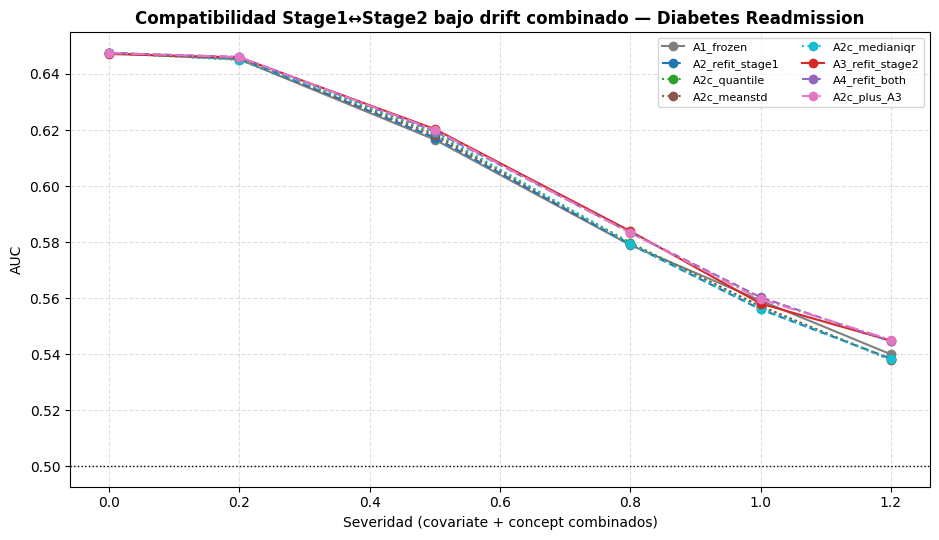

In [7]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
styles = {
    "A1_frozen": ("#7f7f7f", "-"),
    "A2_refit_stage1": ("#1f77b4", "--"),
    "A2c_quantile": ("#2ca02c", ":"),
    "A2c_meanstd": ("#8c564b", ":"),
    "A2c_medianiqr": ("#17becf", ":"),
    "A3_refit_stage2": ("#d62728", "-"),
    "A4_refit_both": ("#9467bd", "--"),
    "A2c_plus_A3": ("#e377c2", "-."),
}
for action, (color, ls) in styles.items():
    ax.plot(df_auc_pivot.index, df_auc_pivot[action], marker="o", label=action, color=color, linestyle=ls)
ax.axhline(0.5, color="black", linestyle=":", linewidth=1)
ax.set_xlabel("Severidad (covariate + concept combinados)")
ax.set_ylabel("AUC")
ax.set_title("Compatibilidad Stage1↔Stage2 bajo drift combinado — Diabetes Readmission", fontweight="bold")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 6. Validación — `P(X)` bajo drift combinado

In [8]:
stability_rows = []
for sev in SEVERITIES:
    cov_sev = min(sev, 1.0)
    df_cov_target, _ = cov_inj.transform(df_target, drift_severity=cov_sev, drift_type="covariate", numeric_drift_config=NUM_CFG)
    df_combined_target, _ = concept_inj.transform(df_cov_target, severity=sev, mechanism=CONCEPT_MECHANISM)
    for col in CLINICAL_VARS:
        ks = ks_stat(df_target[col], df_combined_target[col])
        psi = psi_numeric(df_target[col], df_combined_target[col])
        stability_rows.append({"severity": sev, "variable": col, "ks_stat": ks["ks_stat"], "psi": psi})

df_stability = pd.DataFrame(stability_rows)
df_stability.pivot(index="variable", columns="severity", values="ks_stat")

severity,0.0,0.2,0.5,0.8,1.0,1.2
variable,,,,,,
num_lab_procedures,0.038955,0.153954,0.376954,0.606485,0.757406,0.761605
num_medications,0.060648,0.178213,0.455797,0.736412,0.901563,0.905528
num_procedures,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
number_diagnoses,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
number_emergency,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
number_inpatient,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
number_outpatient,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
time_in_hospital,0.169116,0.156286,0.390716,0.617681,0.768136,0.769069


## 7. Guardar artefactos

In [9]:
from darl.utils import find_project_root

OUT_DIR = find_project_root() / "outputs" / "metrics"
OUT_DIR.mkdir(parents=True, exist_ok=True)

df_results.to_csv(OUT_DIR / "gap1_gap2_compatibility_combined_drift_diabetes.csv", index=False)
df_stability.to_csv(OUT_DIR / "gap1_gap2_combined_x_stability_diabetes.csv", index=False)

print("Artefactos guardados en", OUT_DIR)

Artefactos guardados en C:\Users\dayan\OneDrive\Documentos\GitHub\tesis-darl\outputs\metrics


## 8. Conclusiones

- Con el bug de `DriftInjector` evitado, la comparación de acciones queda limpia: A1 degrada de forma
  moderada y ordenada (0.647→0.540), en línea con lo ya visto para concept drift puro en Diabetes.

### Las 3 formas de corregir X dan el mismo resultado (no era el método)

Un compañero señaló que en `poc_compatibility.ipynb` se usa mediana/IQR en vez del mapeo por
cuantiles que usamos para A2c. Se probaron las tres variantes lado a lado:

| Severidad | A2c (cuantiles) | A2c (media/std) | A2c (mediana/IQR) | A1 (referencia) |
|---|---|---|---|---|
| 0.5 | 0.6185 | 0.6181 | 0.6193 | 0.6166 |
| 0.8 | 0.5798 | 0.5794 | 0.5793 | 0.5789 |
| 1.2 | 0.5381 | 0.5379 | 0.5381 | 0.5399 |

**Las tres dan prácticamente el mismo número**, y las tres se quedan pegadas a A1 (diferencias de
0.0002 entre métodos, contra una caída de 0.11 puntos de A1 a lo largo de las severidades). Esto
confirma que el hallazgo "corregir X no ayuda aquí" no depende de qué tan sofisticado sea el método
de corrección — cuantiles, media/std o mediana/IQR son todos igual de inútiles, porque el problema no
está en cómo se corrige X, está en que corregir X no es lo que hace falta. Tiene sentido con la nota
metodológica del compañero en `poc_compatibility.ipynb`: el drift de `DriftInjector` reemplaza valores
fila por fila, así que ninguna corrección marginal (columna por columna, sea cual sea) puede
deshacerlo — solo reentrenar puede, porque no depende de deshacer nada.

### El resultado que NO replica el patrón de Physionet

A diferencia de `compatibility_combined_drift.ipynb` (Physionet), donde A3/A4 recuperaban dramáticamente
el AUC frente a A1/A2/A2c, **aquí ninguna acción se separa de forma significativa de A1** — ni siquiera
reentrenando Stage 2 (A3/A4), y mucho menos con cualquiera de las 3 variantes de A2c:

| Severidad | A1 | A2c (cualquier método) | A3 | A4 | A2c+A3 |
|---|---|---|---|---|---|
| 0.5 | 0.617 | ~0.618 | 0.620 | 0.620 | 0.620 |
| 0.8 | 0.579 | ~0.579 | 0.584 | 0.583 | 0.583 |
| 1.2 | 0.540 | ~0.538 | 0.545 | 0.544 | 0.545 |

Todas las acciones quedan dentro de ~1 punto porcentual de AUC entre sí. **Conclusión:** el hallazgo
"A3 sola basta, no hace falta A4" de Physionet no es una regla general, y ahora sabemos con más certeza
que el motivo no es "el método de corrección elegido" — hace falta investigar otra causa (tamaño de
muestra, o las variables específicas que sí se desplazaron).

**Próximos pasos:** diagnosticar por qué A3/A4 no recuperan aquí antes de fijar una acción por defecto
para el entorno de RL (Gap 3); probar con covariate shift sobre `number_inpatient` (el coeficiente más
fuerte del modelo de concepto) una vez resuelto el bug de `DriftInjector` con variables zero-inflated.